# 03 — Experimento final e drift

Apresentação dos artefatos verificados. Não executa treinamento nem avaliação. Sem resultados finais, permanece explicitamente pendente.

In [1]:
from pathlib import Path
import os
import sys
raiz = Path.cwd()
if not (raiz / 'analisar_dados_drift.py').exists():
    raiz = raiz.parent
assert (raiz / 'analisar_dados_drift.py').exists(), 'Abra o notebook dentro do repositorio.'
os.chdir(raiz)
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))
import pandas as pd
import json
from IPython.display import display, Markdown, Image

from analisar_resultados_finais import conferir_execucao
final = Path('resultados/final')
analises = Path('resultados/analises_finais')
pronto = (final / 'manifesto_resultados.json').exists()
if pronto:
    protocolo = conferir_execucao(final)
else:
    display(Markdown('**Pendente:** revisar e congelar o protocolo, depois executar o experimento final. Este notebook não treina modelos nem abre D2.'))
analises_prontas = pronto and (analises / 'manifesto_analises.json').exists()
if analises_prontas:
    from protocolo_final import sha256
    manifesto = json.loads((analises / 'manifesto_analises.json').read_text(encoding='utf-8'))
    assert manifesto['resultados_sha256'] == sha256(final / 'manifesto_resultados.json')
    assert manifesto['protocolo_sha256'] == sha256(final / 'protocolo_congelado.json')
    for nome, digest in manifesto['arquivos'].items():
        caminho = (analises / nome).resolve()
        assert caminho.is_relative_to(analises.resolve()) and sha256(caminho) == digest
elif pronto:
    display(Markdown('**Pendente:** executar analisar_resultados_finais.py para gerar as análises.'))


## Estratégias

M0: MLP treinada em D0. MFT: continua os pesos de M0 em D1, mantendo o scaler de D0. MRT: MLP nova em D0+D1. MREC: MLP nova apenas em D1. GB e regressão logística são comparadores treinados em D0. Todos são treinados antes da leitura de D2; o limiar fica congelado.

In [2]:
if pronto:
    display(Markdown((final/'RELATORIO.md').read_text(encoding='utf-8')))
    display(pd.read_csv(final/'resumo.csv'))

# E12 — Avaliacao final

| Modelo | MCC | Desvio entre seeds | Diferenca vs M0 |
|---|---:|---:|---:|
| GB | 0.1978 | 0.0000 | +0.0356 |
| LR | 0.1309 | nan | -0.0314 |
| M0 | 0.1623 | 0.0021 | +0.0000 |
| MFT | 0.1681 | 0.0069 | +0.0058 |
| MREC | 0.1715 | 0.0053 | +0.0093 |
| MRT | 0.1789 | 0.0064 | +0.0166 |

Desvio amostral ddof=1; LR deterministica tem uma execucao (seed=-1) e desvio indefinido. PR-AUC e average precision; ROC-AUC indefinida se houver uma unica classe. Tempos de MFT separam atualizacao e custo total desde M0. Complexidade de GB e um limite superior de folhas, nao contagem de pesos. A comparacao central usa M0/MFT/MRT/MREC; GB e LR sao baselines historicos. Os desvios entre sementes nao sao intervalos de confianca para a populacao.


,modelo,execucoes,mcc_media,mcc_desvio,f1_media,f1_desvio,precision_media,precision_desvio,recall_media,recall_desvio,pr_auc_media,pr_auc_desvio,roc_auc_media,roc_auc_desvio,accuracy_media,accuracy_desvio,delta_mcc_vs_m0,delta_mcc_relativo
0,GB,3,0.197843,0.000000,0.455691,6.798700e-17,0.456140,6.798700e-17,0.455242,6.798700e-17,0.465740,6.798700e-17,0.661105,0.000000,0.650070,0.000000,0.035556,0.219098
1,LR,1,0.130878,NaN,0.394451,NaN,0.418035,NaN,0.373386,NaN,0.399459,NaN,0.587180,NaN,0.631127,NaN,-0.031408,-0.193536
2,M0,3,0.162286,0.002102,0.346987,1.209338e-02,0.483701,1.029069e-02,0.271029,1.827806e-02,0.437715,5.699890e-03,0.635988,0.007153,0.672136,0.004376,0.000000,0.000000
3,MFT,3,0.168127,0.006942,0.330843,2.262154e-02,0.503349,6.062394e-03,0.247173,2.698838e-02,0.457340,1.644606e-03,0.661768,0.000273,0.679155,0.001930,0.005840,0.035988
4,MREC,3,0.171540,0.005258,0.334453,1.346166e-02,0.506400,1.117895e-02,0.250091,1.703552e-02,0.469013,5.204629e-03,0.671594,0.001118,0.680094,0.003572,0.009254,0.057024
5,MRT,3,0.178900,0.006409,0.365451,1.063173e-02,0.495776,1.608508e-02,0.290071,1.926065e-02,0.457757,6.055095e-03,0.658109,0.003489,0.676244,0.006578,0.016614,0.102375


## Execuções, custo e convergência

O desvio é amostral entre sementes, não um intervalo de confiança. A regressão determinística tem uma execução. MFT separa custo de atualização e custo incluindo o treinamento de M0. Avisos de convergência ficam registrados.

In [3]:
if pronto:
    display(pd.read_csv(final/'metricas_seeds.csv'))
    display(pd.read_csv(final/'tempos.csv'))
    display(pd.read_csv(final/'treinamento.csv'))

,modelo,seed,tempo_inferencia_s,mcc,f1,precision,recall,pr_auc,roc_auc,accuracy,tn,fp,fn,tp
0,M0,42,0.004664,0.164654,0.338837,0.492487,0.258262,0.444232,0.644247,0.675704,8415,1216,3389,1180
1,MRT,42,0.004308,0.184301,0.361924,0.506095,0.281681,0.461508,0.657373,0.680423,8375,1256,3282,1287
2,MREC,42,0.004769,0.168552,0.319578,0.512313,0.232217,0.467604,0.672860,0.681831,8621,1010,3508,1061
3,MFT,42,0.004508,0.175144,0.356030,0.496476,0.277522,0.458117,0.662056,0.676972,8345,1286,3301,1268
4,M0,1337,0.004506,0.161562,0.341242,0.486235,0.262858,0.435256,0.631752,0.673451,8362,1269,3368,1201
5,MRT,1337,0.004386,0.171819,0.377398,0.477242,0.312103,0.450772,0.655047,0.668662,8069,1562,3143,1426
6,MREC,1337,0.004548,0.168457,0.345798,0.493506,0.266141,0.464657,0.670744,0.675986,8383,1248,3353,1216
7,MFT,1337,0.004461,0.167972,0.324244,0.507937,0.238127,0.458453,0.661734,0.680634,8577,1054,3481,1088
8,M0,2024,0.004447,0.160642,0.360882,0.472380,0.291968,0.433657,0.631966,0.667254,8141,1490,3235,1334
9,MRT,2024,0.004422,0.180580,0.357032,0.503990,0.276428,0.460992,0.661907,0.679648,8388,1243,3306,1263


,modelo,seed,dados_treino,tempo_treino_s,tempo_desde_zero_s,convergiu,avisos,iteracoes,complexidade,tipo_complexidade,tempo_inferencia_s
0,M0,42,D0,5.225202,5.225202,True,NaN,111,705,pesos_e_vieses,0.004664
1,MRT,42,D0+D1,4.791673,4.791673,True,NaN,80,705,pesos_e_vieses,0.004308
2,MREC,42,D1,2.299154,2.299154,True,NaN,144,705,pesos_e_vieses,0.004769
3,MFT,42,D0 -> D1,0.022814,5.248017,NaN,Epocas fixas; convergencia nao e criterio de p...,1,705,pesos_e_vieses,0.004508
4,M0,1337,D0,3.912995,3.912995,True,NaN,81,705,pesos_e_vieses,0.004506
5,MRT,1337,D0+D1,4.601674,4.601674,True,NaN,77,705,pesos_e_vieses,0.004386
6,MREC,1337,D1,2.128958,2.128958,True,NaN,151,705,pesos_e_vieses,0.004548
7,MFT,1337,D0 -> D1,0.019749,3.932744,NaN,Epocas fixas; convergencia nao e criterio de p...,1,705,pesos_e_vieses,0.004461
8,M0,2024,D0,3.457833,3.457833,True,NaN,76,705,pesos_e_vieses,0.004447
9,MRT,2024,D0+D1,5.995075,5.995075,True,NaN,102,705,pesos_e_vieses,0.004422


,modelo,seed,dados_treino,tempo_treino_s,tempo_desde_zero_s,convergiu,avisos,iteracoes,complexidade,tipo_complexidade
0,M0,42,D0,5.225202,5.225202,True,NaN,111,705,pesos_e_vieses
1,MRT,42,D0+D1,4.791673,4.791673,True,NaN,80,705,pesos_e_vieses
2,MREC,42,D1,2.299154,2.299154,True,NaN,144,705,pesos_e_vieses
3,MFT,42,D0 -> D1,0.022814,5.248017,NaN,Epocas fixas; convergencia nao e criterio de p...,1,705,pesos_e_vieses
4,M0,1337,D0,3.912995,3.912995,True,NaN,81,705,pesos_e_vieses
5,MRT,1337,D0+D1,4.601674,4.601674,True,NaN,77,705,pesos_e_vieses
6,MREC,1337,D1,2.128958,2.128958,True,NaN,151,705,pesos_e_vieses
7,MFT,1337,D0 -> D1,0.019749,3.932744,NaN,Epocas fixas; convergencia nao e criterio de p...,1,705,pesos_e_vieses
8,M0,2024,D0,3.457833,3.457833,True,NaN,76,705,pesos_e_vieses
9,MRT,2024,D0+D1,5.995075,5.995075,True,NaN,102,705,pesos_e_vieses


## Mudança entre períodos

PSI, KS, Wasserstein e Jensen–Shannon descrevem diferenças de distribuição. Mudança dos atributos ou da frequência do alvo, isoladamente, não prova concept drift. Os intervalos de PSI são definidos no primeiro período de cada comparação.

,conjunto,linhas,proporcao_alvo
0,D0,42800,0.361612
1,D1,14200,0.313028
2,D2,14200,0.321761


,atributo,tipo,ks,psi,wasserstein,wasserstein_por_iqr_referencia,js_bits,media_referencia,media_recente,referencia,recente
0,rank,numerico,1.110223e-16,0.000000,0.000000,0.000000,NaN,50.500000,50.500000,D0,D1
1,rank_lag1,numerico,3.698039e-02,0.014388,1.129969,0.020925,NaN,53.078411,54.208380,D0,D1
2,rank_lag2,numerico,5.281197e-02,0.020006,1.986344,0.033106,NaN,55.426262,57.412606,D0,D1
3,variacao_1s,numerico,7.075918e-02,0.075151,4.349277,0.483253,NaN,2.578411,3.708380,D0,D1
4,peak_pos,numerico,1.028847e-01,0.045803,5.529121,0.108414,NaN,38.382290,32.853169,D0,D1
...,...,...,...,...,...,...,...,...,...,...,...
58,digital_presente,categorico,NaN,NaN,NaN,NaN,0.012811,0.285211,0.173592,D1,D2
59,album_presente,categorico,NaN,NaN,NaN,NaN,0.011920,0.458380,0.586620,D1,D2
60,mes,categorico,NaN,NaN,NaN,NaN,0.014927,6.788732,6.119718,D1,D2
61,semana_ano,categorico,NaN,NaN,NaN,NaN,0.013297,27.570423,24.823944,D1,D2


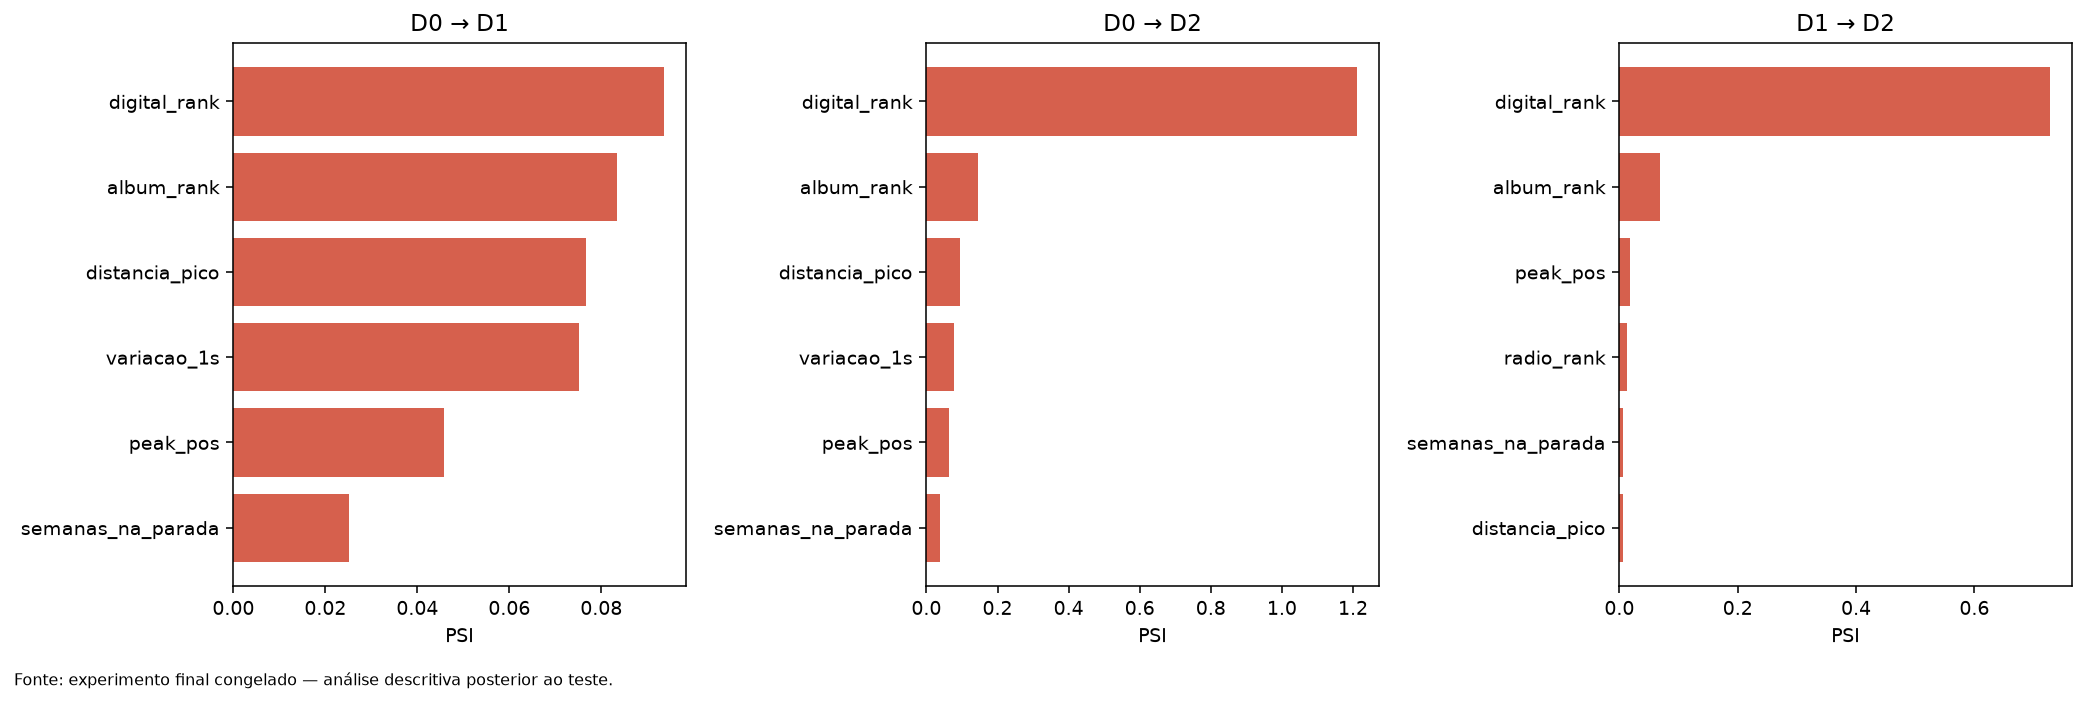

,modelo,seed,conjunto,mcc,f1,precision,recall,pr_auc,roc_auc,accuracy,tn,fp,fn,tp,tempo_inferencia_s
0,M0,42,D0,0.355442,0.541344,0.652479,0.462557,0.627881,0.766278,0.716565,23510,3813,8318,7159,NaN
1,M0,42,D1,0.203466,0.365843,0.522556,0.281440,0.471257,0.689891,0.694577,8612,1143,3194,1251,NaN
2,M0,1337,D0,0.363220,0.562150,0.638410,0.502165,0.627069,0.764256,0.717126,22921,4402,7705,7772,NaN
3,M0,1337,D1,0.218559,0.394114,0.522677,0.316310,0.474299,0.681591,0.695563,8471,1284,3039,1406,NaN
4,M0,2024,D0,0.372505,0.583669,0.623751,0.548427,0.623983,0.763121,0.717079,22203,5120,6989,8488,NaN
5,M0,2024,D1,0.223479,0.415654,0.511506,0.350056,0.474407,0.684549,0.691901,8269,1486,2889,1556,NaN
6,M0,42,D2,0.164654,0.338837,0.492487,0.258262,0.444232,0.644247,0.675704,8415,1216,3389,1180,0.004664
7,M0,1337,D2,0.161562,0.341242,0.486235,0.262858,0.435256,0.631752,0.673451,8362,1269,3368,1201,0.004506
8,M0,2024,D2,0.160642,0.360882,0.472380,0.291968,0.433657,0.631966,0.667254,8141,1490,3235,1334,0.004447


In [4]:
if analises_prontas:
    display(pd.read_csv(analises/'alvo_periodos.csv'))
    display(pd.read_csv(analises/'drift.csv'))
    display(Image(filename=str(analises/'drift.png')))
    display(pd.read_csv(analises/'m0_por_periodo.csv'))

D0 na trajetória de M0 é desempenho de treino; D1 e D2 são períodos posteriores. Não interpretar essa comparação como três testes independentes.